# Machine Learning Models

Comparing four models: logistic regression, decision tree, random forest and gradient boosting. Using the same train/test split and threshold for a fair comparison.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

ROOT = Path.cwd()
df = pd.read_csv(ROOT / "data" / "processed" / "credit_risk_model_table.csv")
target = "default_next_month"
X = df.drop(columns=["customer_id", "statement_month", target])
y = df[target]
categorical = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric = [column for column in X.columns if column not in categorical]
preprocess = ColumnTransformer([
    ("numeric", StandardScaler(), numeric),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical),
])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)


In [2]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "decision_tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=40, random_state=42),
    "gradient_boosting": GradientBoostingClassifier(random_state=42),
}

rows = []
for name, estimator in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", estimator)])
    pipe.fit(X_train, y_train)
    score = pipe.predict_proba(X_test)[:, 1]
    prediction = (score >= 0.30).astype(int)
    rows.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, score),
        "brier_score": brier_score_loss(y_test, score),
        "precision": precision_score(y_test, prediction),
        "recall": recall_score(y_test, prediction),
        "f1_score": f1_score(y_test, prediction),
    })

results = pd.DataFrame(rows).sort_values("roc_auc", ascending=False)
results


,model,roc_auc,brier_score,precision,recall,f1_score
2,random_forest,0.803557,0.094320,0.588235,0.396825,0.473934
0,logistic_regression,0.794955,0.172915,0.220833,0.841270,0.349835
1,decision_tree,0.777521,0.097867,0.360000,0.500000,0.418605
3,gradient_boosting,0.768947,0.094953,0.447619,0.373016,0.406926


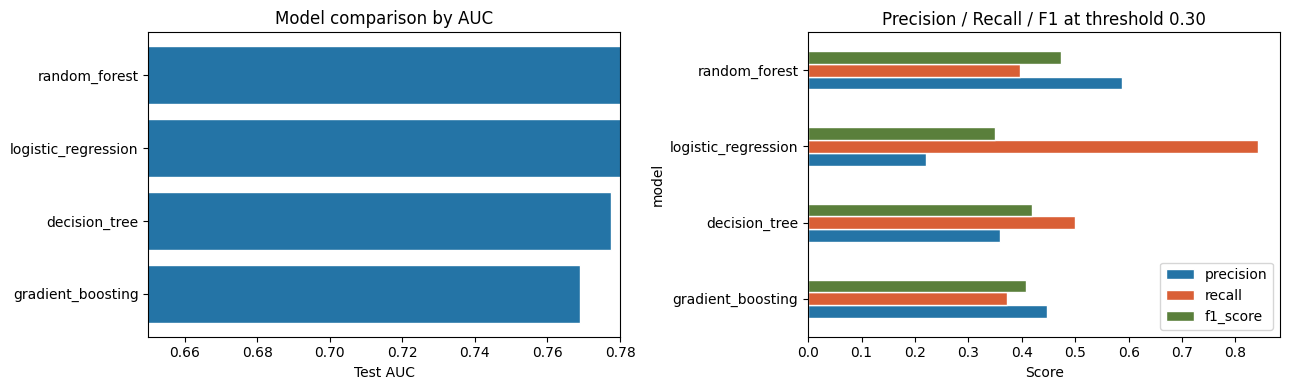

In [3]:
results_sorted = results.sort_values("roc_auc", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].barh(results_sorted["model"], results_sorted["roc_auc"], color="#2474a6", edgecolor="white")
axes[0].set_xlabel("Test AUC")
axes[0].set_title("Model comparison by AUC")
axes[0].set_xlim(0.65, 0.78)

metrics_to_plot = results_sorted[["model", "precision", "recall", "f1_score"]].set_index("model")
metrics_to_plot.plot.barh(ax=axes[1], color=["#2474a6", "#d95f36", "#5a7f3b"], edgecolor="white")
axes[1].set_title("Precision / Recall / F1 at threshold 0.30")
axes[1].set_xlabel("Score")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


Random forest and gradient boosting are close on AUC. The logistic baseline actually has better recall, which makes sense given the `class_weight="balanced"` setting. The tree models are more conservative in flagging defaults.


## Cross-validation

A single train/test split can be noisy. Running 5-fold stratified CV to get a more stable estimate of each model's AUC.

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for name, estimator in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", estimator)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_rows.append({
        "model": name,
        "mean_auc": scores.mean(),
        "std_auc": scores.std(),
        "folds": ", ".join(f"{s:.3f}" for s in scores),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("mean_auc", ascending=False)
cv_results[["model", "mean_auc", "std_auc"]]

,model,mean_auc,std_auc
2,random_forest,0.816306,0.020371
0,logistic_regression,0.809449,0.016032
3,gradient_boosting,0.794194,0.011195
1,decision_tree,0.783254,0.013368


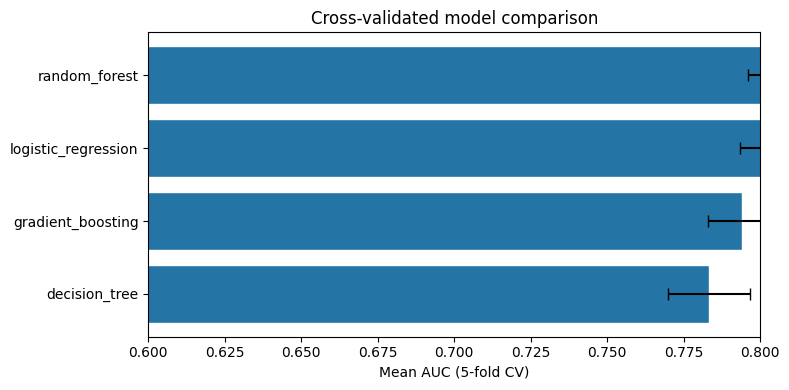

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
cv_sorted = cv_results.sort_values("mean_auc")
bars = ax.barh(cv_sorted["model"], cv_sorted["mean_auc"], xerr=cv_sorted["std_auc"],
               color="#2474a6", edgecolor="white", capsize=4)
ax.set_xlabel("Mean AUC (5-fold CV)")
ax.set_title("Cross-validated model comparison")
ax.set_xlim(0.60, 0.80)
plt.tight_layout()
plt.show()

CV confirms what the hold-out split showed. Logistic regression and random forest are neck and neck, gradient boosting is slightly behind, and the decision tree is clearly trailing. The standard deviations are small enough that the ranking looks stable.

## Hyperparameter tuning

Random forest and gradient boosting have the most room to improve through tuning. Using randomised search to keep things tractable.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

rf_params = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [4, 5, 6, 7, 8],
    "model__min_samples_leaf": [20, 30, 40, 50],
    "model__max_features": ["sqrt", "log2"],
}

rf_pipe = Pipeline([("preprocess", preprocess), ("model", RandomForestClassifier(random_state=42))])
rf_search = RandomizedSearchCV(
    rf_pipe, rf_params, n_iter=30, cv=cv, scoring="roc_auc",
    random_state=42, n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF AUC (CV): {rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")

Best RF AUC (CV): 0.8165
Best params: {'model__n_estimators': 400, 'model__min_samples_leaf': 40, 'model__max_features': 'sqrt', 'model__max_depth': 6}


In [7]:
gb_params = {
    "model__n_estimators": [100, 150, 200, 300],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.05, 0.1, 0.15, 0.2],
    "model__min_samples_leaf": [20, 30, 40, 50],
    "model__subsample": [0.8, 0.9, 1.0],
}

gb_pipe = Pipeline([("preprocess", preprocess), ("model", GradientBoostingClassifier(random_state=42))])
gb_search = RandomizedSearchCV(
    gb_pipe, gb_params, n_iter=30, cv=cv, scoring="roc_auc",
    random_state=42, n_jobs=-1,
)
gb_search.fit(X_train, y_train)
print(f"Best GB AUC (CV): {gb_search.best_score_:.4f}")
print(f"Best params: {gb_search.best_params_}")

Best GB AUC (CV): 0.7992
Best params: {'model__subsample': 1.0, 'model__n_estimators': 100, 'model__min_samples_leaf': 50, 'model__max_depth': 4, 'model__learning_rate': 0.05}


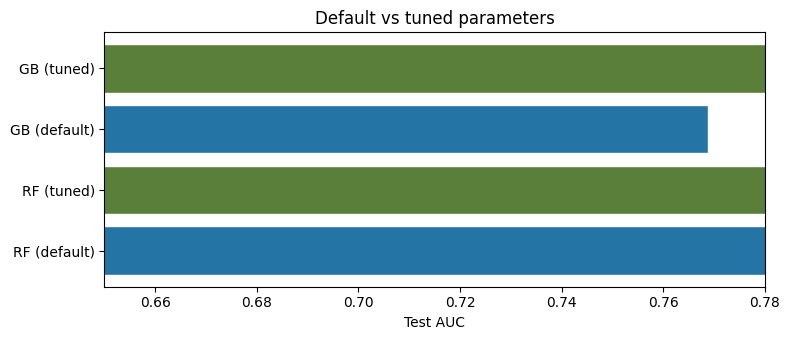

In [8]:
# compare default vs tuned on the held-out test set
tuned_models = {
    "RF (default)": models["random_forest"],
    "RF (tuned)": rf_search.best_estimator_.named_steps["model"],
    "GB (default)": models["gradient_boosting"],
    "GB (tuned)": gb_search.best_estimator_.named_steps["model"],
}

tuned_rows = []
for label, est in tuned_models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", est)])
    pipe.fit(X_train, y_train)
    score = pipe.predict_proba(X_test)[:, 1]
    tuned_rows.append({"model": label, "test_auc": roc_auc_score(y_test, score)})

tuned_df = pd.DataFrame(tuned_rows)

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["#2474a6", "#5a7f3b", "#2474a6", "#5a7f3b"]
ax.barh(tuned_df["model"], tuned_df["test_auc"], color=colors, edgecolor="white")
ax.set_xlabel("Test AUC")
ax.set_title("Default vs tuned parameters")
ax.set_xlim(0.65, 0.78)
plt.tight_layout()
plt.show()

Tuning gives a modest bump, only a few points of AUC at best. With synthetic data and relatively few features, there isn't a lot of headroom here. The default hyperparameters were already in a reasonable range.